#### imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

In [2]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")
EVENT_GROUP = 'Storm'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Preparation

In [3]:
df = pd.read_csv(DATASET_PATH)

### Group by event type

In [4]:
df['EVENT_GROUP'].value_counts()

EVENT_GROUP
Wind           152966
Hail            57980
Storm           55795
Flood           49691
Freeze          39347
Drought         20115
Snow            19792
Heat            14279
Heavy Rain      10488
Fog              4943
Wildfire         2505
Lightning        2261
Debris Flow      1047
Avalanche         203
Name: count, dtype: int64

In [5]:
event_group_dfs = {
    'Hail': df[df['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df[df['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df[df['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df[df['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df[df['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df[df['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df[df['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df[df['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df[df['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df[df['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df[df['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df[df['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df[df['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df[df['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [6]:
event_group_dfs['Hail'].head()

,DAMAGES,CASUALTIES,DURATION_HOURS,HAIL_SIZE,TIME_DAY_SIN,TIME_DAY_COS,TIME_YEAR_NORM,PRECIPITATION,TMIN,TMAX,...,SLOPE,COV_BARREN,COV_CULTIVATED,COV_VEGETATION,COV_FOREST,COV_WATER,COV_SNOW_ICE,COV_URBAN,RIVER_DISTANCE,SEA_DISTANCE
65,0.0,0,0.0,1.00,0.154204,0.988039,0.0,1404.65,11.66,22.69,...,1.89,0.000,0.716,0.146,0.136,0.002,0.0,0.000,256.4,415.3
72,0.0,0,0.0,0.88,0.353445,0.935455,0.0,1519.92,12.85,24.73,...,6.01,0.003,0.120,0.047,0.769,0.040,0.0,0.021,1082.0,170.3
74,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1478.56,12.41,24.58,...,5.17,0.000,0.328,0.094,0.538,0.001,0.0,0.040,515.2,217.7
76,100.0,0,0.0,1.75,0.353445,0.935455,0.0,1589.20,12.37,24.92,...,7.35,0.000,0.049,0.020,0.930,0.001,0.0,0.000,925.4,142.4
82,0.0,0,0.0,1.00,0.353445,0.935455,0.0,1437.68,12.31,24.38,...,4.94,0.000,0.183,0.119,0.467,0.018,0.0,0.212,377.5,223.6


In [7]:
df = event_group_dfs[EVENT_GROUP]

### Data normalization

In [8]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

In [9]:
X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

In [10]:
# targets log transformation
Y = np.log1p(Y)

In [11]:
# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [12]:
# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)


### Dataset split

In [13]:
# conversion to tensors and move to device
X_train = torch.tensor(X_train).to(device)
Y_train = torch.tensor(Y_train).to(device)

X_val = torch.tensor(X_val).to(device)
Y_val = torch.tensor(Y_val).to(device)

X_test = torch.tensor(X_test).to(device)
Y_test = torch.tensor(Y_test).to(device)


In [14]:
# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)

## Model

### Model definition

In [ ]:
EPOCHS = 100
BATCH_SIZE = 512
BASE_LR = 5e-3

# find warmup steps as function of epochs and dataset size
WARMUP_STEPS = int(0.1 * (len(train_ds) // BATCH_SIZE) * EPOCHS)

In [26]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=12,
    hidden_features=[128, 128],
    bins=8
)

In [27]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [28]:
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=WARMUP_STEPS
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS * len(train_loader) - WARMUP_STEPS,
    eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_STEPS]
)

scaler = torch.amp.GradScaler(device=device)

ema = torch.optim.swa_utils.AveragedModel(
    flow,
    avg_fn=lambda averaged, model, num_averaged: 0.999 * averaged + 0.001 * model
)

In [29]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 306216 parameters


### Model training

In [30]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [31]:
history = TrainingHistory()
best_val_loss = np.inf
global_step = 0

for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type):
            loss = -flow(x).log_prob(y).mean()

        scaler.scale(loss).backward()

        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        ema.update_parameters(flow)

        train_loss += loss.item()
        global_step += 1

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    flow.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:03d} | "
        f"Time {time.time()-t0:.2f}s | "
        f"Train NLL {train_loss:.3f} | "
        f"Val NLL {val_loss:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    # Save EMA weights (better than raw model)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ema.module.state_dict(), RUN_PATH)


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 000 | Time 8.47s | Train NLL -1.025 | Val NLL -2.564 | LR 9.56e-04
Epoch 001 | Time 8.61s | Train NLL -2.331 | Val NLL -1.131 | LR 1.41e-03
Epoch 002 | Time 8.30s | Train NLL -2.762 | Val NLL -3.593 | LR 1.87e-03
Epoch 003 | Time 8.88s | Train NLL -3.082 | Val NLL -2.438 | LR 2.32e-03
Epoch 004 | Time 8.35s | Train NLL -2.509 | Val NLL -4.686 | LR 2.78e-03
Epoch 005 | Time 8.55s | Train NLL -2.246 | Val NLL 2.136 | LR 3.24e-03
Epoch 006 | Time 8.72s | Train NLL -2.552 | Val NLL -3.643 | LR 3.69e-03
Epoch 007 | Time 8.27s | Train NLL -2.966 | Val NLL -4.636 | LR 4.15e-03
Epoch 008 | Time 8.50s | Train NLL -3.057 | Val NLL -3.122 | LR 4.60e-03


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 009 | Time 8.50s | Train NLL -2.385 | Val NLL -2.768 | LR 5.00e-03
Epoch 010 | Time 6.03s | Train NLL -3.318 | Val NLL -2.265 | LR 5.00e-03
Epoch 011 | Time 6.40s | Train NLL -3.752 | Val NLL -4.933 | LR 4.99e-03
Epoch 012 | Time 6.48s | Train NLL -3.248 | Val NLL -2.558 | LR 4.99e-03
Epoch 013 | Time 6.28s | Train NLL -2.728 | Val NLL -4.053 | LR 4.97e-03
Epoch 014 | Time 6.33s | Train NLL -3.748 | Val NLL -3.927 | LR 4.96e-03
Epoch 015 | Time 6.52s | Train NLL -3.413 | Val NLL -4.139 | LR 4.94e-03
Epoch 016 | Time 6.32s | Train NLL -4.119 | Val NLL -5.750 | LR 4.92e-03
Epoch 017 | Time 6.53s | Train NLL -2.835 | Val NLL -4.297 | LR 4.90e-03
Epoch 018 | Time 6.43s | Train NLL -3.474 | Val NLL -5.523 | LR 4.87e-03
Epoch 019 | Time 6.43s | Train NLL -3.944 | Val NLL -5.295 | LR 4.85e-03
Epoch 020 | Time 7.29s | Train NLL -4.786 | Val NLL -3.535 | LR 4.81e-03
Epoch 021 | Time 8.56s | Train NLL -4.800 | Val NLL -3.887 | LR 4.78e-03
Epoch 022 | Time 8.37s | Train NLL -4.231 | Val NLL

### Model Evaluation

In [32]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

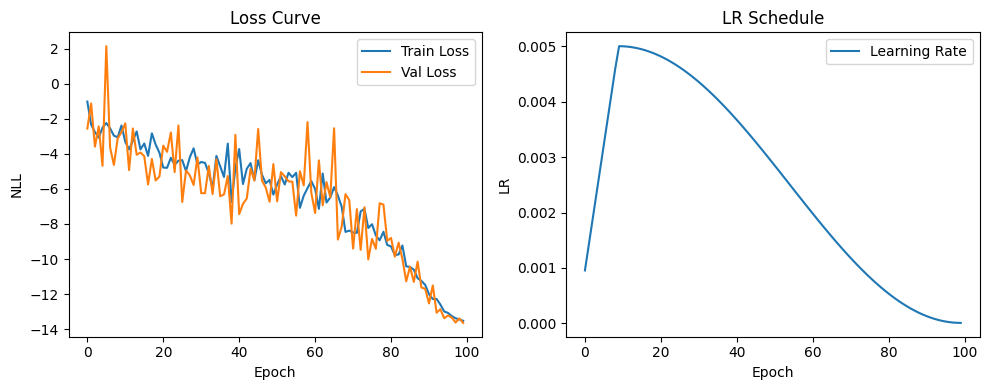

In [33]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


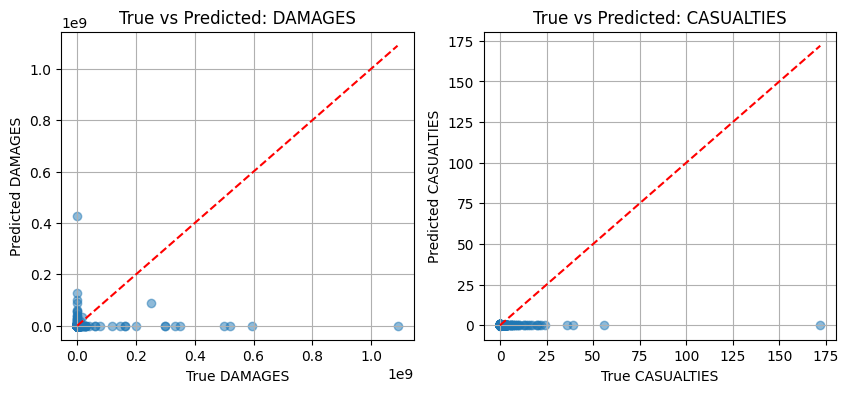

In [34]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

In [35]:
# compute average true/predicted damagesdifference
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Compute average difference for damages
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    avg_diff_casualties = np.mean(np.abs(y_true[:, 1] - y_pred[:, 1]))
    print(f"Average absolute difference in {TARGET_COLS[0]}: {avg_diff_damages:.2f}")
    print(f"Average absolute difference in {TARGET_COLS[1]}: {avg_diff_casualties:.2f}") 
compute_avg_true_pred_diff(flow, test_loader, y_scaler)

Average absolute difference in DAMAGES: 794050.12
Average absolute difference in CASUALTIES: 0.10


## Model - hybrid loss

### Model definition

In [ ]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=12,
    hidden_features=[128, 128],
    bins=8
)

In [ ]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [ ]:
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=WARMUP_STEPS
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS * len(train_loader) - WARMUP_STEPS,
    eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_STEPS]
)

scaler = torch.amp.GradScaler(device=device)

ema = torch.optim.swa_utils.AveragedModel(
    flow,
    avg_fn=lambda averaged, model, num_averaged: 0.999 * averaged + 0.001 * model
)

In [ ]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 306216 parameters


### Model training

In [ ]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [ ]:
history = TrainingHistory()
best_val_loss = np.inf
global_step = 0
beta_max = 0.2

for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type):
            dist = flow(x)
            nll = -dist.log_prob(y).mean()
            # Monte Carlo samples
            K = 16
            samples = dist.rsample((K,))  # [K, B, D]
            # Decision rule (mean prediction)
            y_pred = samples.mean(0)
            # Example asymmetric cost
            under = torch.relu(y - y_pred)
            over  = torch.relu(y_pred - y)
            cost = (5.0 * under + over).mean()
            beta = beta_max * min(1.0, epoch / 20) # beta annealing
            loss = nll + beta * cost

        scaler.scale(loss).backward()

        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        ema.update_parameters(flow)

        train_loss += loss.item()
        global_step += 1

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    flow.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:03d} | "
        f"Time {time.time()-t0:.2f}s | "
        f"Train NLL {train_loss:.3f} | "
        f"Val NLL {val_loss:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    # Save EMA weights (better than raw model)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ema.module.state_dict(), RUN_PATH)


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 000 | Time 37.85s | Train NLL -1.205 | Val NLL -2.554 | LR 9.56e-04
Epoch 001 | Time 34.05s | Train NLL -2.411 | Val NLL -2.630 | LR 1.41e-03
Epoch 002 | Time 34.08s | Train NLL -2.731 | Val NLL -2.740 | LR 1.87e-03
Epoch 003 | Time 33.92s | Train NLL -3.277 | Val NLL -3.643 | LR 2.32e-03
Epoch 004 | Time 34.15s | Train NLL -2.139 | Val NLL 0.418 | LR 2.78e-03
Epoch 005 | Time 34.31s | Train NLL -2.835 | Val NLL -0.695 | LR 3.24e-03
Epoch 006 | Time 34.45s | Train NLL -2.783 | Val NLL -3.503 | LR 3.69e-03
Epoch 007 | Time 34.97s | Train NLL -3.293 | Val NLL -2.969 | LR 4.15e-03
Epoch 008 | Time 34.82s | Train NLL -2.522 | Val NLL -3.097 | LR 4.60e-03


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 009 | Time 34.60s | Train NLL -3.490 | Val NLL -2.959 | LR 5.00e-03
Epoch 010 | Time 34.77s | Train NLL -3.057 | Val NLL -3.877 | LR 5.00e-03
Epoch 011 | Time 34.71s | Train NLL -2.903 | Val NLL -4.842 | LR 4.99e-03
Epoch 012 | Time 34.97s | Train NLL -2.931 | Val NLL -5.445 | LR 4.99e-03
Epoch 013 | Time 34.78s | Train NLL -3.353 | Val NLL -5.308 | LR 4.97e-03
Epoch 014 | Time 34.73s | Train NLL -4.227 | Val NLL -5.988 | LR 4.96e-03
Epoch 015 | Time 34.87s | Train NLL -5.641 | Val NLL -6.603 | LR 4.94e-03
Epoch 016 | Time 34.87s | Train NLL -4.363 | Val NLL -6.084 | LR 4.92e-03
Epoch 017 | Time 35.02s | Train NLL -4.781 | Val NLL -4.967 | LR 4.90e-03
Epoch 018 | Time 34.93s | Train NLL -4.391 | Val NLL -6.718 | LR 4.87e-03
Epoch 019 | Time 35.03s | Train NLL -4.139 | Val NLL -5.046 | LR 4.85e-03
Epoch 020 | Time 35.85s | Train NLL -4.974 | Val NLL -4.660 | LR 4.81e-03
Epoch 021 | Time 35.12s | Train NLL -4.937 | Val NLL -5.718 | LR 4.78e-03
Epoch 022 | Time 35.18s | Train NLL -5

### Model Evaluation

In [ ]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

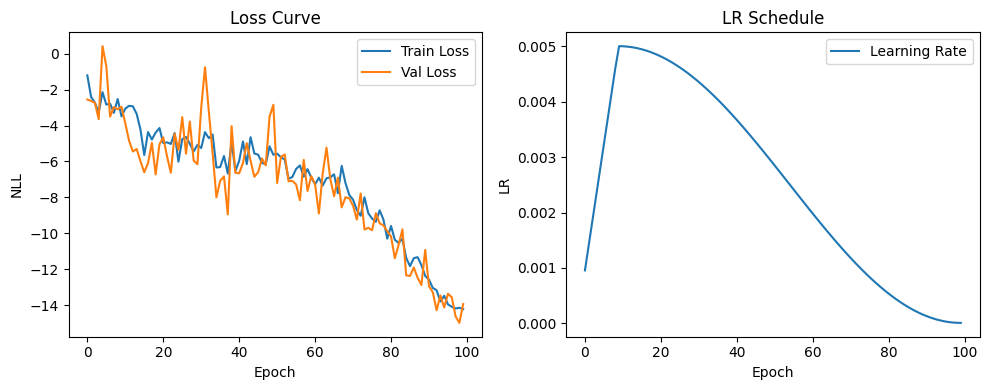

In [ ]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


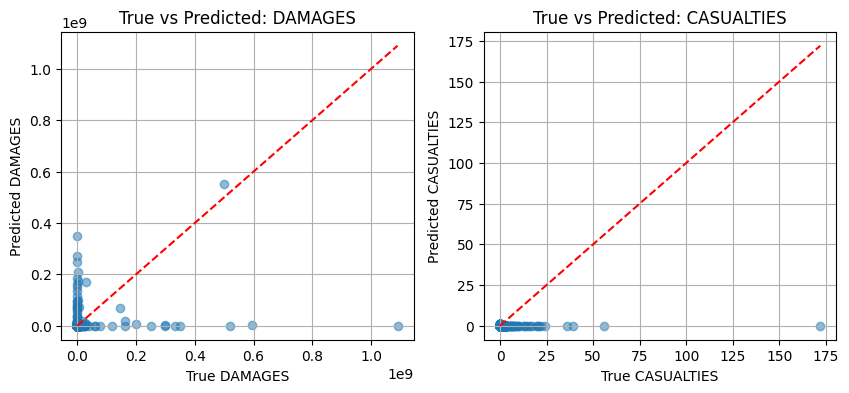

In [ ]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

In [ ]:
# compute average true/predicted damagesdifference
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Compute average difference for damages
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    avg_diff_casualties = np.mean(np.abs(y_true[:, 1] - y_pred[:, 1]))
    print(f"Average absolute difference in {TARGET_COLS[0]}: {avg_diff_damages:.2f}")
    print(f"Average absolute difference in {TARGET_COLS[1]}: {avg_diff_casualties:.2f}") 
compute_avg_true_pred_diff(flow, test_loader, y_scaler)

Average absolute difference in DAMAGES: 990987.81
Average absolute difference in CASUALTIES: 0.10


## Model - Pure Asymmetric Likelihood

### Model definition

In [36]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=12,
    hidden_features=[128, 128],
    bins=8
)

In [37]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [38]:
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=WARMUP_STEPS
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS * len(train_loader) - WARMUP_STEPS,
    eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_STEPS]
)

scaler = torch.amp.GradScaler(device=device)

ema = torch.optim.swa_utils.AveragedModel(
    flow,
    avg_fn=lambda averaged, model, num_averaged: 0.999 * averaged + 0.001 * model
)

In [39]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 306216 parameters


### Model training

In [40]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [41]:
history = TrainingHistory()
best_val_loss = np.inf
global_step = 0
beta = 0.05
threshold = 100000

for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type):
            dist = flow(x)
            log_prob = dist.log_prob(y)
            extreme = (y > threshold).any(dim=1)
            weight = 1 + 4 * extreme.float()
            loss = -(weight * log_prob).mean()

        scaler.scale(loss).backward()

        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        ema.update_parameters(flow)

        train_loss += loss.item()
        global_step += 1

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    flow.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:03d} | "
        f"Time {time.time()-t0:.2f}s | "
        f"Train NLL {train_loss:.3f} | "
        f"Val NLL {val_loss:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    # Save EMA weights (better than raw model)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ema.module.state_dict(), RUN_PATH)


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 000 | Time 6.63s | Train NLL -1.566 | Val NLL -3.541 | LR 9.56e-04
Epoch 001 | Time 6.70s | Train NLL -2.414 | Val NLL -2.935 | LR 1.41e-03
Epoch 002 | Time 6.43s | Train NLL -2.737 | Val NLL -1.373 | LR 1.87e-03
Epoch 003 | Time 6.48s | Train NLL -2.593 | Val NLL -3.681 | LR 2.32e-03
Epoch 004 | Time 6.87s | Train NLL -2.570 | Val NLL -3.765 | LR 2.78e-03
Epoch 005 | Time 6.52s | Train NLL -2.069 | Val NLL -3.734 | LR 3.24e-03
Epoch 006 | Time 6.42s | Train NLL -3.551 | Val NLL 0.011 | LR 3.69e-03
Epoch 007 | Time 6.63s | Train NLL -3.238 | Val NLL -2.273 | LR 4.15e-03
Epoch 008 | Time 6.67s | Train NLL -2.786 | Val NLL -4.102 | LR 4.60e-03


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 009 | Time 7.13s | Train NLL -2.399 | Val NLL -2.120 | LR 5.00e-03
Epoch 010 | Time 7.17s | Train NLL -3.355 | Val NLL -5.620 | LR 5.00e-03
Epoch 011 | Time 7.64s | Train NLL -3.060 | Val NLL -3.810 | LR 4.99e-03
Epoch 012 | Time 6.54s | Train NLL -2.159 | Val NLL -2.000 | LR 4.99e-03
Epoch 013 | Time 6.48s | Train NLL -3.467 | Val NLL -4.598 | LR 4.97e-03
Epoch 014 | Time 6.83s | Train NLL -3.716 | Val NLL -4.896 | LR 4.96e-03
Epoch 015 | Time 6.45s | Train NLL -3.602 | Val NLL -2.069 | LR 4.94e-03
Epoch 016 | Time 6.46s | Train NLL -2.438 | Val NLL -2.644 | LR 4.92e-03
Epoch 017 | Time 6.71s | Train NLL -4.110 | Val NLL -4.943 | LR 4.90e-03
Epoch 018 | Time 6.49s | Train NLL -3.791 | Val NLL -5.189 | LR 4.87e-03
Epoch 019 | Time 6.63s | Train NLL -4.311 | Val NLL -5.145 | LR 4.85e-03
Epoch 020 | Time 6.42s | Train NLL -4.924 | Val NLL -5.261 | LR 4.81e-03
Epoch 021 | Time 6.50s | Train NLL -4.699 | Val NLL -5.575 | LR 4.78e-03
Epoch 022 | Time 6.50s | Train NLL -4.288 | Val NLL

### Model Evaluation

In [42]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

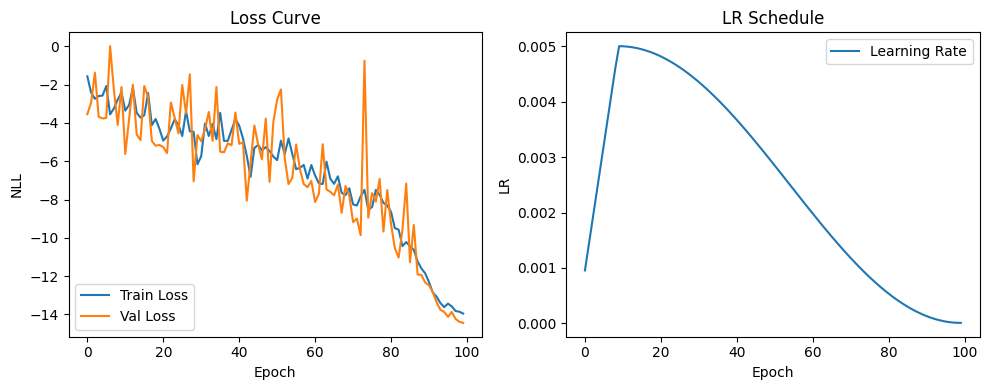

In [43]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


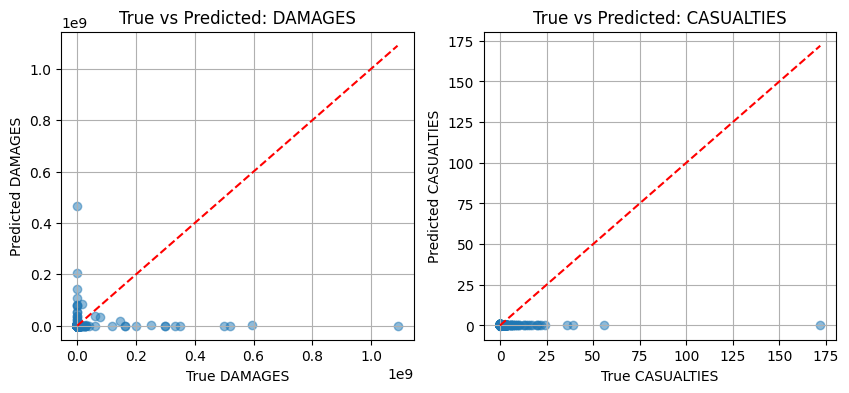

In [44]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

In [45]:
# compute average true/predicted damagesdifference
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Compute average difference for damages
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    avg_diff_casualties = np.mean(np.abs(y_true[:, 1] - y_pred[:, 1]))
    print(f"Average absolute difference in {TARGET_COLS[0]}: {avg_diff_damages:.2f}")
    print(f"Average absolute difference in {TARGET_COLS[1]}: {avg_diff_casualties:.2f}") 
compute_avg_true_pred_diff(flow, test_loader, y_scaler)

Average absolute difference in DAMAGES: 765073.69
Average absolute difference in CASUALTIES: 0.10


## Model - Quantile-Oriented Training

### Model definition

In [46]:
X_DIM = X_train.shape[1]
Y_DIM = 2   # DAMAGES, CASUALTIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=12,
    hidden_features=[128, 128],
    bins=8
)

In [47]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [48]:
flow = flow.to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=BASE_LR, weight_decay=1e-5)

warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    total_iters=WARMUP_STEPS
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS * len(train_loader) - WARMUP_STEPS,
    eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_STEPS]
)

scaler = torch.amp.GradScaler(device=device)

ema = torch.optim.swa_utils.AveragedModel(
    flow,
    avg_fn=lambda averaged, model, num_averaged: 0.999 * averaged + 0.001 * model
)

In [49]:
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 306216 parameters


### Model training

In [50]:
class TrainingHistory:
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.lrs = []

In [51]:
history = TrainingHistory()
best_val_loss = np.inf
global_step = 0
beta = 0.05

for epoch in range(EPOCHS):
    t0 = time.time()
    flow.train()
    train_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type):
            dist = flow(x)
            nll = -dist.log_prob(y).mean()
            samples = dist.rsample((32,))
            q90 = samples.quantile(0.9, dim=0)
            pinball = torch.maximum(
                0.9 * (y - q90),
                0.1 * (q90 - y)
            ).mean()
            loss = nll + beta * pinball


        scaler.scale(loss).backward()

        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        ema.update_parameters(flow)

        train_loss += loss.item()
        global_step += 1

    train_loss /= len(train_loader)

    # ---------- Validation ----------
    flow.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            loss = -flow(x).log_prob(y).mean()
            val_loss += loss.item()

    val_loss /= len(val_loader)

    history.train_losses.append(train_loss)
    history.val_losses.append(val_loss)
    history.lrs.append(optimizer.param_groups[0]["lr"])

    print(
        f"Epoch {epoch:03d} | "
        f"Time {time.time()-t0:.2f}s | "
        f"Train NLL {train_loss:.3f} | "
        f"Val NLL {val_loss:.3f} | "
        f"LR {optimizer.param_groups[0]['lr']:.2e}"
    )

    # Save EMA weights (better than raw model)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ema.module.state_dict(), RUN_PATH)


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 000 | Time 60.59s | Train NLL -1.980 | Val NLL -3.474 | LR 9.56e-04
Epoch 001 | Time 60.90s | Train NLL -3.167 | Val NLL -2.870 | LR 1.41e-03
Epoch 002 | Time 61.42s | Train NLL -3.364 | Val NLL -3.600 | LR 1.87e-03
Epoch 003 | Time 61.58s | Train NLL -1.930 | Val NLL -1.172 | LR 2.32e-03
Epoch 004 | Time 61.80s | Train NLL -2.857 | Val NLL -2.110 | LR 2.78e-03
Epoch 005 | Time 61.83s | Train NLL -3.514 | Val NLL -4.089 | LR 3.24e-03
Epoch 006 | Time 62.05s | Train NLL -2.941 | Val NLL -3.475 | LR 3.69e-03
Epoch 007 | Time 62.00s | Train NLL -3.779 | Val NLL -3.660 | LR 4.15e-03
Epoch 008 | Time 62.20s | Train NLL -3.297 | Val NLL -4.088 | LR 4.60e-03


c:\Users\matti\anaconda3\envs\ai311\Lib\site-packages\torch\optim\lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 009 | Time 62.35s | Train NLL -3.031 | Val NLL -2.380 | LR 5.00e-03
Epoch 010 | Time 62.35s | Train NLL -3.104 | Val NLL -5.765 | LR 5.00e-03
Epoch 011 | Time 62.32s | Train NLL -3.178 | Val NLL -0.541 | LR 4.99e-03
Epoch 012 | Time 62.35s | Train NLL -2.006 | Val NLL -1.885 | LR 4.99e-03
Epoch 013 | Time 62.35s | Train NLL -3.284 | Val NLL -2.676 | LR 4.97e-03
Epoch 014 | Time 62.40s | Train NLL -4.183 | Val NLL -4.340 | LR 4.96e-03
Epoch 015 | Time 62.33s | Train NLL -4.874 | Val NLL -2.490 | LR 4.94e-03
Epoch 016 | Time 62.48s | Train NLL -4.859 | Val NLL -6.142 | LR 4.92e-03
Epoch 017 | Time 62.28s | Train NLL -4.797 | Val NLL -4.330 | LR 4.90e-03
Epoch 018 | Time 62.43s | Train NLL -3.796 | Val NLL -3.767 | LR 4.87e-03
Epoch 019 | Time 62.52s | Train NLL -4.482 | Val NLL -3.948 | LR 4.85e-03
Epoch 020 | Time 62.53s | Train NLL -5.113 | Val NLL -4.714 | LR 4.81e-03
Epoch 021 | Time 62.39s | Train NLL -5.066 | Val NLL -6.713 | LR 4.78e-03
Epoch 022 | Time 62.38s | Train NLL -5

### Model Evaluation

In [52]:
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)

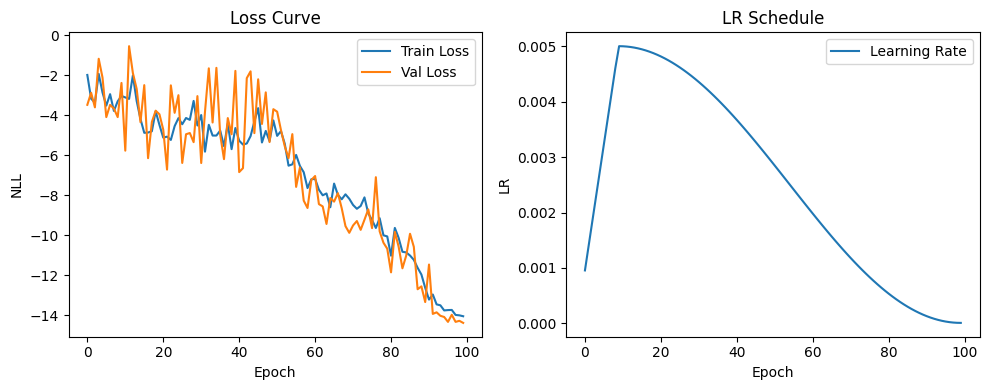

In [53]:
# plot training curves (loss and learning rate)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.train_losses, label='Train Loss')
plt.plot(history.val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('NLL')
plt.title('Loss Curve')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.lrs, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('LR Schedule')
plt.legend()
plt.tight_layout()
plt.show()


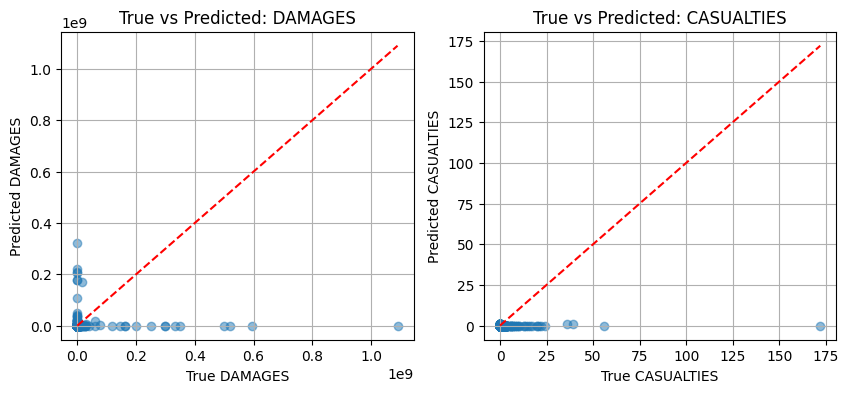

In [54]:
# Run inference for the test set and plot results for damages and casualties
def run_inference_and_plot(flow, test_loader, y_scaler, target_cols):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Plot for each target
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.scatter(y_true[:, 0], y_pred[:, 0], alpha=0.5)
    plt.xlabel(f"True {target_cols[0]}")
    plt.ylabel(f"Predicted {target_cols[0]}")
    plt.title(f"True vs Predicted: {target_cols[0]}")
    plt.plot([y_true[:, 0].min(), y_true[:, 0].max()], [y_true[:, 0].min(), y_true[:, 0].max()], 'r--')
    plt.grid()
    plt.subplot(1,2,2)
    plt.scatter(y_true[:, 1], y_pred[:, 1], alpha=0.5)
    plt.xlabel(f"True {target_cols[1]}")
    plt.ylabel(f"Predicted {target_cols[1]}")
    plt.title(f"True vs Predicted: {target_cols[1]}")
    plt.plot([y_true[:, 1].min(), y_true[:, 1].max()], [y_true[:, 1].min(), y_true[:, 1].max()], 'r--')
    plt.grid()
    plt.show()

run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS)

In [55]:
# compute average true/predicted damagesdifference
def compute_avg_true_pred_diff(flow, test_loader, y_scaler):
    flow.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            # Get the distribution and sample from it
            dist = flow(x_batch)
            y_hat = dist.sample().squeeze(1)  # shape: [batch, 2]
            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    # Inverse scale
    y_true = y_scaler.inverse_transform(y_true)
    y_pred = y_scaler.inverse_transform(y_pred)
    y_pred = np.expm1(np.clip(y_pred, -20, None))
    y_true = np.expm1(np.clip(y_true, -20, None))
    # Compute average difference for damages
    avg_diff_damages = np.mean(np.abs(y_true[:, 0] - y_pred[:, 0]))
    avg_diff_casualties = np.mean(np.abs(y_true[:, 1] - y_pred[:, 1]))
    print(f"Average absolute difference in {TARGET_COLS[0]}: {avg_diff_damages:.2f}")
    print(f"Average absolute difference in {TARGET_COLS[1]}: {avg_diff_casualties:.2f}") 
compute_avg_true_pred_diff(flow, test_loader, y_scaler)

Average absolute difference in DAMAGES: 892266.69
Average absolute difference in CASUALTIES: 0.10
